<a href="https://colab.research.google.com/github/NikolaiMiranda/customer-segmentation-retail/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [106]:
import pandas as pd
from datetime import timedelta
from ucimlrepo import fetch_ucirepo
from sklearn.metrics import davies_bouldin_score
import numpy as np

Gather and clean the data:

In [118]:
# fetch dataset
online_retail = fetch_ucirepo(id=352)

# create a dataframe to hold the data
# reading through the documentation for ucimlrepo we find that our data is split into dataframe labeled "ids" and "features"
# we will joing those together to form one dataframe
# Check that both dataframes are the same length and then join them
print(len(online_retail.data.ids) == len(online_retail.data.features))
df = online_retail.data.ids.join(online_retail.data.features)

True


In [119]:
# View the data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [120]:
# Check if we have null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [121]:
# We have missing cutomer IDs
# We remove these since we need the IDs to match customers to their purchases and segment them
df = df.dropna(subset=['CustomerID'])

# Check to make sure null values have been discarded
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [114]:
# The documentation states that if an order is cancelled the InvoiceNo will start with a 'c'
# We will remove all canceled orders from the data since we want to segment customers based on their purchases
df['InvoiceNo'].astype(str).str.startswith('C')
# Note: ~ inverts the boolean

# Not sure how I should deal with cancelled orders
# Could be good to remiove them for certain stats but also won't effect spend stats because the sum of the original purchase and the cancelled one cancel out


AttributeError: 'Series' object has no attribute 'startswith'

In [ ]:
df[]

In [ ]:
df[]

In [ ]:
len(df)
# 406829 total orders

406829

In [ ]:
len(df[df['StockCode'] == 'D'])

77

In [ ]:
len(df[df['StockCode'] == 'M'])

465

In [ ]:
one_char_codes = df[df['StockCode'].astype(str).str.len() == 1]['StockCode'].unique()
print(one_char_codes)


['D' 'M']


In [147]:
df[df['InvoiceNo'].astype(str).str.startswith('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [128]:
# Step 3: Identify cancellations and normalize Quantity
df_cancel = df[df['InvoiceNo'].str.startswith('C')].copy()
df_cancel['Quantity'] = -df_cancel['Quantity']
df_original = df[~df['InvoiceNo'].str.startswith('C')].copy()

# Print cancellation count for debugging (should be ~8905)
print(f"Number of cancellation rows: {len(df_cancel)}")

# Step 4: Merge to find matching pairs (line-item level)
matched = pd.merge(
    df_original,
    df_cancel,
    on=['StockCode', 'Description', 'CustomerID', 'Country'],
    suffixes=('_original', '_cancel')
)

# Step 5: To remove specific matched original rows (not whole invoices), add a temporary index to originals
df_original['temp_index'] = df_original.index

# Merge again to get the original indices of matched rows
matched_with_index = pd.merge(
    df_original,
    df_cancel,
    on=['StockCode', 'Description', 'CustomerID', 'Country'],
    suffixes=('_original', '_cancel')
)[['temp_index']]

# Get the indices of matched original rows to drop
indices_to_drop = matched_with_index['temp_index'].unique()

# Step 6: Remove matched original rows and all cancellations from the full df
# First, remove all cancellations
df_cleaned = df[~df['InvoiceNo'].str.startswith('C')]

# Then, drop the specific matched original rows by index
df_cleaned = df_cleaned.drop(indices_to_drop)
# NOTE THAT WE SAVE THIS BACK AS DF_CLEANED, NEED TO ADJUST REST OF SHEET

Number of cancellation rows: 8905


In [148]:
# Step 3: Identify cancellations and normalize Quantity
df_cancel = df[df['InvoiceNo'].str.startswith('C')].copy()
df_cancel['Quantity'] = -df_cancel['Quantity']  # flip sign so it's positive for matching
df_original = df[~df['InvoiceNo'].str.startswith('C')].copy()

# Clean text fields to avoid whitespace/case mismatches
for col in ['Description', 'StockCode']:
    df_original[col] = df_original[col].astype(str).str.strip().str.lower()
    df_cancel[col]   = df_cancel[col].astype(str).str.strip().str.lower()

# Fill NaNs in match fields
df_original['CustomerID'] = df_original['CustomerID'].fillna(-1)
df_cancel['CustomerID']   = df_cancel['CustomerID'].fillna(-1)
df_original['Country']    = df_original['Country'].fillna('')
df_cancel['Country']      = df_cancel['Country'].fillna('')

print(f"Number of cancellation rows: {len(df_cancel)}")

# Step 4: Merge originals with cancellations (ignore Quantity in keys)
merged = pd.merge(
    df_original,
    df_cancel,
    on=['StockCode', 'Description', 'CustomerID', 'Country', 'UnitPrice'],
    how='left',
    suffixes=('_original', '_cancel')
)

# Step 5: Adjust quantities for partial/full cancellations
merged['Quantity_cancel'] = merged['Quantity_cancel'].fillna(0)
merged['Quantity_adjusted'] = merged['Quantity_original'] - merged['Quantity_cancel']

# Step 6: Keep only rows where adjusted quantity > 0
df_cleaned = merged[merged['Quantity_adjusted'] > 0].copy()

# Replace the original Quantity column with the adjusted one
df_cleaned['Quantity'] = df_cleaned['Quantity_adjusted']

print(f"Cleaned dataframe rows: {len(df_cleaned)}")


Number of cancellation rows: 8905
Cleaned dataframe rows: 395423


In [160]:
df_cleaned[df_cleaned['Quantity_cancel'] > 0]

,InvoiceNo_original,StockCode,Description,Quantity_original,InvoiceDate_original,UnitPrice,CustomerID,Country,InvoiceNo_cancel,Quantity_cancel,InvoiceDate_cancel,Quantity_adjusted,Quantity
6,536365,21730,glass star frosted t-light holder,6,12/1/2010 8:26,4.25,17850.0,United Kingdom,C543611,1.0,2/10/2011 14:38,5.0,5.0
14,536367,84969,box of 6 assorted colour teaspoons,6,12/1/2010 8:34,4.25,13047.0,United Kingdom,C548374,1.0,3/30/2011 16:36,5.0,5.0
45,536370,post,postage,3,12/1/2010 8:45,18.00,12583.0,France,C543992,1.0,2/15/2011 10:29,2.0,2.0
54,536373,21871,save the planet mug,6,12/1/2010 9:02,1.06,17850.0,United Kingdom,C543611,1.0,2/10/2011 14:38,5.0,5.0
57,536373,82483,wood 2 drawer cabinet white finish,2,12/1/2010 9:02,4.95,17850.0,United Kingdom,C543611,1.0,2/10/2011 14:38,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
402043,581571,21314,small glass heart trinket pot,48,12/9/2011 12:00,1.85,15311.0,United Kingdom,C548857,10.0,4/4/2011 13:28,38.0,38.0
402044,581571,21314,small glass heart trinket pot,48,12/9/2011 12:00,1.85,15311.0,United Kingdom,C550494,1.0,4/18/2011 14:54,47.0,47.0
402045,581571,21314,small glass heart trinket pot,48,12/9/2011 12:00,1.85,15311.0,United Kingdom,C558444,5.0,6/29/2011 13:29,43.0,43.0
402046,581571,21314,small glass heart trinket pot,48,12/9/2011 12:00,1.85,15311.0,United Kingdom,C576561,2.0,11/15/2011 13:22,46.0,46.0


In [ ]:
# Of the 8905, only about 1500 were full cancellations

In [159]:
len(indices_to_drop)

17695

In [158]:
len(df_cleaned)

395423

In [ ]:
# I suspect the difference in number of cancellations and matched orders is primarily from orders whose cancellations came after the data began being collected and so they don't show up so they can't be matched

Feature engineering:

In [ ]:
# Create a total spend variable
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

In [ ]:
# Compute a reference date to use to create a recency variable
# We will calculate recency in terms of number of days from the "current date"
# We willuse the last day in the data set as the "current date"

# Make sure InvoiceDate is of type datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Create a date to reference all other dates against
reference_date = df['InvoiceDate'].max()

In [ ]:
# Create a summary dataframe using our additional features
customer_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days), # Days since last purchase
    Frequency=('InvoiceNo', 'nunique'), # Number of unique invoices
    Monetary=('TotalSpend', 'sum'), # Total spend
    AvgQuantity = ('Quantity', 'mean'), # Average quantity per transaction
    ProductCount = ('StockCode', 'nunique'), # Number of unique products purchased
    Country = ('Country', lambda x: x.mode()[0]) # Most common country
)


customer_df.head()

,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country
CustomerID,,,,,,
12346.0,325,2,0.00,0.000000,1,United Kingdom
12347.0,1,7,4310.00,13.505495,103,Iceland
12348.0,74,4,1797.24,75.516129,22,Finland
12349.0,18,1,1757.55,8.643836,73,Italy
12350.0,309,1,334.40,11.588235,17,Norway


In [ ]:
customer_df.sort_values(by='Monetary', ascending=True)
# Assuming that these negative values from cancellations are a result of cancellations of purchases that occured before the dataset began being collected. Thus we will eliminate these.


,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country
CustomerID,,,,,,
17448.0,144,1,-4287.63,-1.000000,1,United Kingdom
15369.0,143,1,-1592.49,-1.000000,1,United Kingdom
14213.0,371,1,-1192.20,-48.800000,5,United Kingdom
17603.0,49,5,-1165.30,-2.066667,12,United Kingdom
12503.0,337,1,-1126.00,-1.000000,1,Spain
...,...,...,...,...,...,...
12415.0,23,26,123725.45,99.282776,444,Australia
14911.0,0,248,132572.62,13.074708,1794,EIRE
17450.0,7,55,187482.17,196.663818,127,United Kingdom


In [ ]:
len(customer_df[customer_df['Monetary'] < 0])

42

In [ ]:
df[df['CustomerID'] == 15369]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
268431,C560420,M,Manual,-1,2011-07-18 15:11:00,1592.49,15369.0,United Kingdom,-1592.49


In [ ]:
# DO we need to delete these???
df[df['UnitPrice'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany,0.0
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom,0.0
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE,0.0
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom,0.0
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom,0.0
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom,0.0
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom,0.0
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom,0.0
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom,0.0
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom,0.0


Segmentation using K-means:

In [ ]:
# Feature Scaling for K-Means
from sklearn.preprocessing import StandardScaler

# Select the RFM features for clustering
features = customer_df[['Recency', 'Frequency', 'Monetary', 'AvgQuantity', 'ProductCount']] # Consider turning country into a dummy variable

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
customer_df_scaled = scaler.fit_transform(features)

# Convert the scaled array back to a DataFrame for easier handling
customer_df_scaled = pd.DataFrame(customer_df_scaled, columns=features.columns, index=customer_df.index)

customer_df_scaled.head() # Display the first few rows of the scaled data

,Recency,Frequency,Monetary,AvgQuantity,ProductCount
CustomerID,,,,,
12346.0,2.322023,-0.329362,-0.231001,-0.104999,-0.704922
12347.0,-0.893733,0.206102,0.293432,-0.041662,0.489243
12348.0,-0.169196,-0.115176,-0.012316,0.249149,-0.459064
12349.0,-0.725005,-0.436455,-0.017146,-0.064462,0.138018
12350.0,2.163220,-0.436455,-0.190312,-0.050654,-0.517602


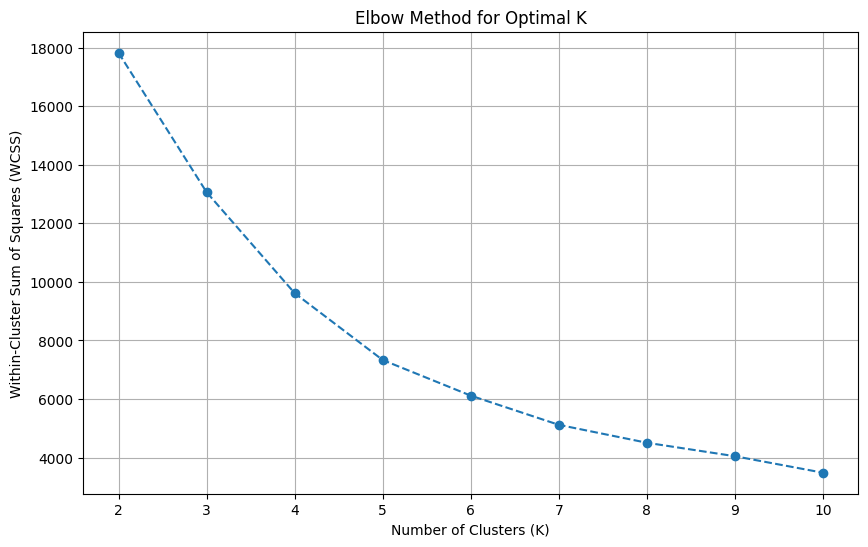

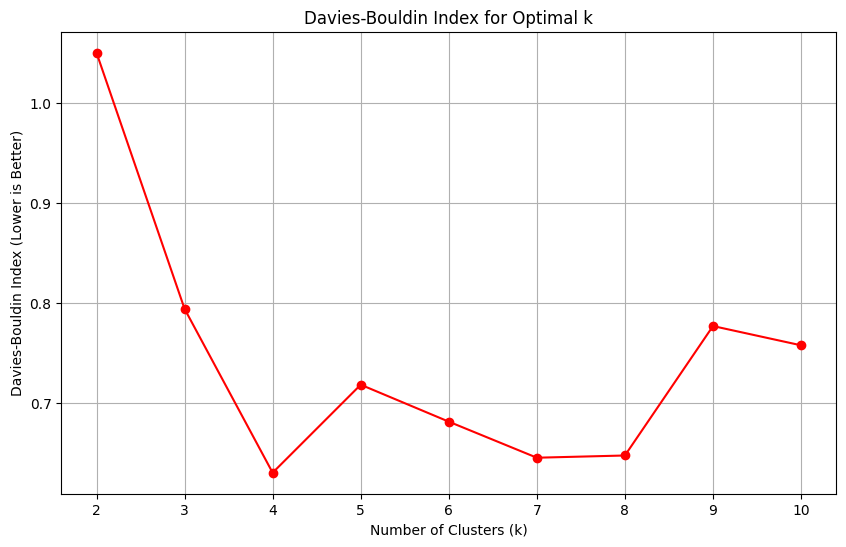

In [ ]:
# Determine optimal number of clusters using the Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

wcss = []
dbi_scores = []
# Test different numbers of clusters from 2 to 10
for i in range(2, 11):
    # Elbow Method
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(customer_df_scaled)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS

    # Davies-Bouldin Index
    dbi = davies_bouldin_score(customer_df_scaled, kmeans.labels_)
    dbi_scores.append(dbi)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

# Plot the Davies-Bouldin Index graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), dbi_scores, marker='o', linestyle='-', color='r')
plt.title('Davies-Bouldin Index for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index (Lower is Better)')
plt.grid(True)
plt.show()

In [ ]:
# Apply K-Means Clustering with K=4
from sklearn.cluster import KMeans

# Initialize KMeans with the chosen K (4)
# n_init='auto' is the modern default for n_init
kmeans = KMeans(n_clusters=4, init='k-means++', n_init='auto', max_iter=300, random_state=42)

# Fit KMeans to the scaled RFM data and get cluster labels
customer_df['Cluster_KMeans'] = kmeans.fit_predict(customer_df_scaled)

customer_df.head() # Display rfm_df with the new Cluster_KMeans column

,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country,Cluster_KMeans
CustomerID,,,,,,,
12346.0,325,2,0.00,0.000000,1,United Kingdom,1
12347.0,1,7,4310.00,13.505495,103,Iceland,0
12348.0,74,4,1797.24,75.516129,22,Finland,0
12349.0,18,1,1757.55,8.643836,73,Italy,0
12350.0,309,1,334.40,11.588235,17,Norway,1


In [ ]:
# Analyze K-Means Cluster Characteristics
# Use customer_df (original, unscaled values) for meaningful averages
customer_df2 = customer_df.reset_index()
kmeans_cluster_analysis = customer_df2.groupby('Cluster_KMeans').agg(
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    CustomerCount=('CustomerID', 'count'), # Assuming CustomerID is now a regular column due to previous reset_index
    AvgQuantity=('AvgQuantity', 'mean'),
    AvgProductCount=('ProductCount', 'mean')
).sort_values(by='AvgMonetary', ascending=False) # Sort by Monetary for easier comparison

kmeans_cluster_analysis

,AvgRecency,AvgFrequency,AvgMonetary,CustomerCount,AvgQuantity,AvgProductCount
Cluster_KMeans,,,,,,
3,3.533333,98.400000,103319.044667,15,55.755907,794.333333
2,15.584034,16.928571,6611.257647,476,16.245020,199.857143
0,44.297403,3.803984,1111.134281,2811,23.587539,48.157595
1,248.660748,1.834579,448.526207,1070,21.506939,23.548598


/tmp/ipython-input-3069119480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer_df2, x='Cluster_KMeans', palette='viridis')


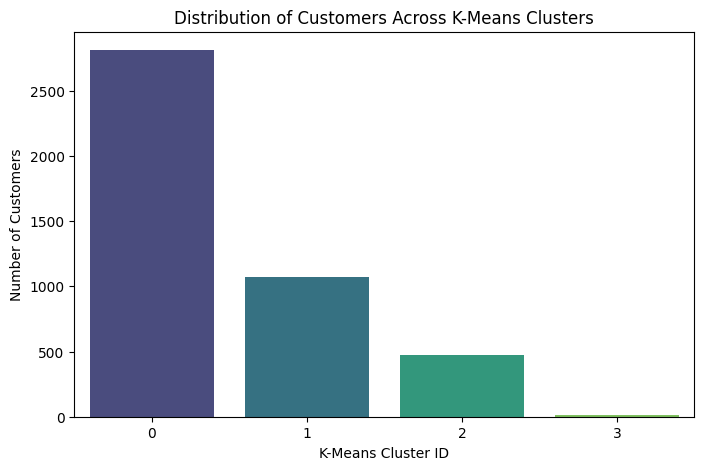

In [ ]:
# Visualize K-Means Cluster Sizes
plt.figure(figsize=(8, 5))
sns.countplot(data=customer_df2, x='Cluster_KMeans', palette='viridis')
plt.title('Distribution of Customers Across K-Means Clusters')
plt.xlabel('K-Means Cluster ID')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
# Map K-Means Cluster IDs to descriptive names

# IMPORTANT: VERIFY THESE MAPPINGS AGAINST YOUR ACTUAL kmeans_cluster_analysis OUTPUT
# The cluster IDs (0, 1, 2) are arbitrary and can change with each run.
# Adjust the dictionary below based on the AvgRecency, AvgFrequency, and AvgMonetary for YOUR Cluster 0, 1, and 2.

# Example mapping (adjust based on your actual output):
# Based on my interpretation in the text above:
# Assuming Cluster 0 is At-Risk/Lapsed
# Assuming Cluster 1 is Champions/Loyal
# Assuming Cluster 2 is Potential/Developing
cluster_name_mapping = {
    0: 'Avg',
    1: 'At-Risk',
    2: 'Loyalists',
    3: 'Elite Members'
}

customer_df2['KMeans_Cluster_Name'] = customer_df2['Cluster_KMeans'].map(cluster_name_mapping)

customer_df2.head() # Display rfm_df with the new KMeans_Cluster_Name column

,CustomerID,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country,Cluster_KMeans,KMeans_Cluster_Name
0,12346.0,325,2,0.00,0.000000,1,United Kingdom,1,At-Risk
1,12347.0,1,7,4310.00,13.505495,103,Iceland,0,Avg
2,12348.0,74,4,1797.24,75.516129,22,Finland,0,Avg
3,12349.0,18,1,1757.55,8.643836,73,Italy,0,Avg
4,12350.0,309,1,334.40,11.588235,17,Norway,1,At-Risk


In [ ]:
# Count customers in each named K-Means cluster
customer_df2['KMeans_Cluster_Name'].value_counts()

,count
KMeans_Cluster_Name,
Avg,2811
At-Risk,1070
Loyalists,476
Elite Members,15
